In [4]:
import sys
sys.path.append("..")
from utils import *

---

> TODO : dire si les résultats sont stables

## Moyenne de deux vecteurs

### Q1

On divise par 3 car on a 3 vecteurs.

In [2]:
cache_l1 = int(round(512/(3*16),0))
cache_l2 = int(round(16_000/(3*16),0))
cache_l3 = int(round(22_000/(3*2),0))

caches_core = {
    "L1": cache_l1,
    "L2": cache_l2,
    "L3": cache_l3,
    "L3 × 2": 2*cache_l3,
}

caches_full = caches_core.copy()


# Ajoute les multiples pairs de L1 et L2 jusqu'à 16
for i in range(2, 17, 2):
    caches_full[f"L1 × {i}"] = cache_l1 * i
    caches_full[f"L2 × {i}"] = cache_l2 * i

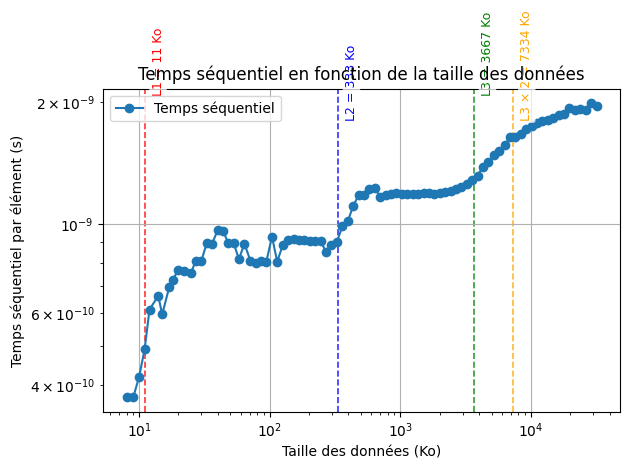

In [6]:
path="results/resultats.txt"
afficher_temps_sequentiel_vs_taille(path, caches_core)

Lorsque le cache est chaud, le temps d’exécution est principalement déterminé par les opérations de lecture disque. Le temps d’exécution séquentiel par point augmente de manière significative à chaque dépassement de cache. Cette augmentation traduit le surcoût induit par le chargement des données depuis un niveau de stockage moins favorable. La dégradation de performance induit n'est pas proportionnelle à la taille des données, elle dépend des espaces mémoire disponibles et leur vitesse de lecture respectives.

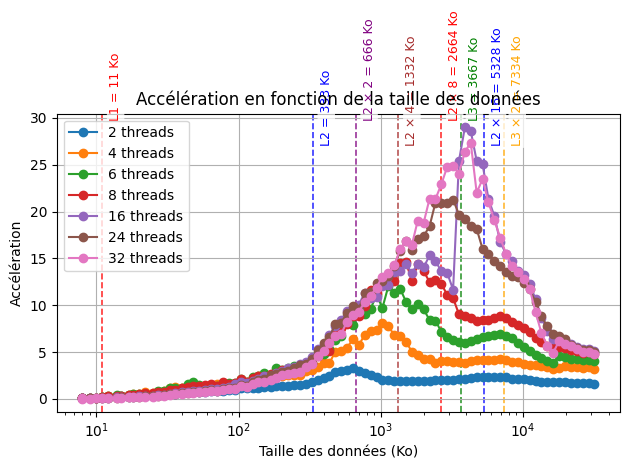

In [5]:
path="results/resultats.txt"
caches = caches_core.copy()

# Ajoute les multiples pairs de L1 et L2 jusqu'à 16
for i in [2,4,8,16]:
    caches[f"L2 × {i}"] = cache_l2 * i
afficher_acceleration_toutes_tailles(path, threads=[2,4,8,6,16,24,32], caches=caches)

Chaque cœur disposant de ses propres caches L1 et L2, on observe que la diminution de l’accélération lors du passage à un niveau de cache moins favorable survient pour des tailles de données qui augmentent proportionnellement au nombre de cœurs utilisés. Notre machine possède deux CPU de 8 cœurs chacun. Lorsque les deux CPU sont sollicités, deux caches L3 sont disponibles, ce qui explique la baisse de performance observée autour de 7334 Ko pour les configurations utilisant plus de 8 threads (les cœurs physiques étant alors obligatoirement répartis sur les deux cpu). Le fait que ce phénomène soit également visible dès 6 threads indique que le scheduler répartit la charge entre les deux CPU afin d’exploiter au mieux les ressources disponibles.

> TODO : expliquer le temps perdu à partir de 17 threads

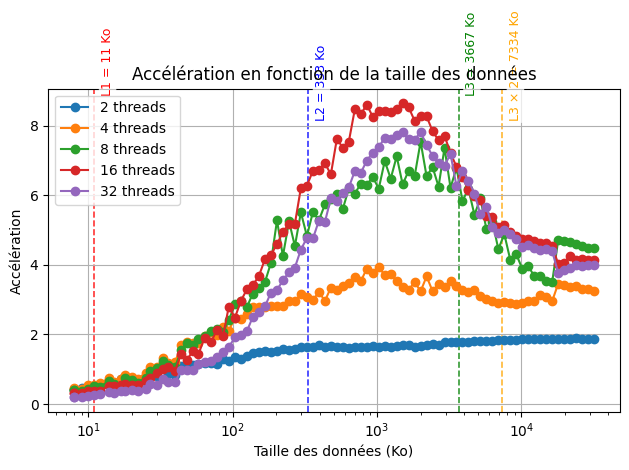

In [18]:
path="results/resultats_cf.txt"
afficher_acceleration_toutes_tailles(path, threads=[2,4,8,16,32], caches=caches_core)

### Q2

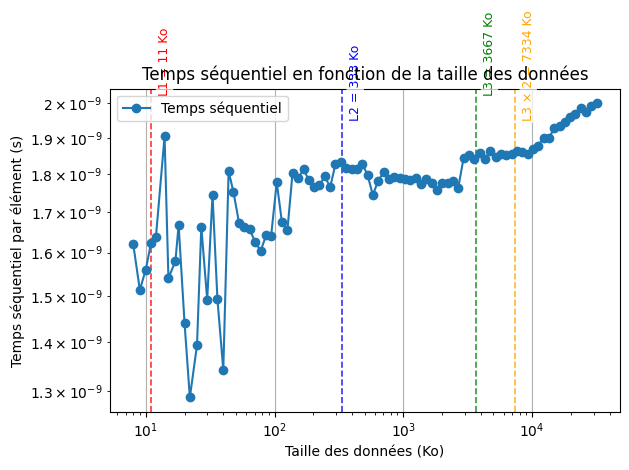

In [20]:
path="results/resultats_cf.txt"
afficher_temps_sequentiel_vs_taille(path, caches=caches_core)

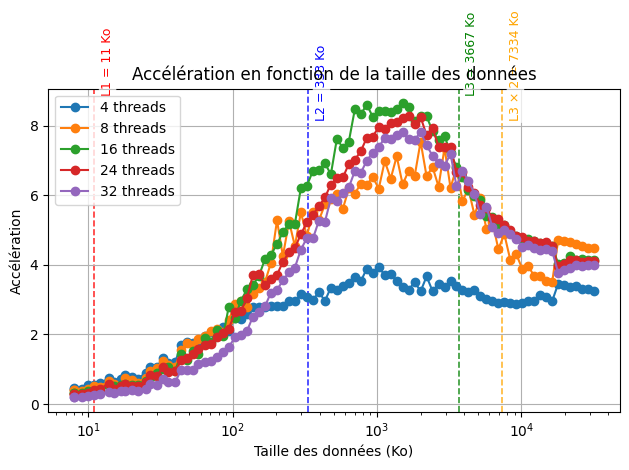

In [23]:
path="results/resultats_cf.txt"
afficher_acceleration_toutes_tailles(path, threads=[4,8,16,24, 32], caches=caches_core)

**Petites tailles (8 à ~50 Ko), accélération < 1**: Le coût de création, de réveil et de synchronisation des threads dépasse le gain. Plus le nombre de threads est élevé moins bonnes sont les performances.

**Montée (~50 Ko à ~1 Mo), pic à 7-8:** Le coût fixe de la parallélisation (réveil des threads, barrière) est progressivement amorti, car le travail par thread augmente alors que ce coût reste constant. À 1 Mo par vecteur, chaque thread traite ~190 Ko (3 vecteurs répartis sur 16 threads). Les 16 cœurs émettent leurs propres requêtes mémoire en parallèle sans saturer la bande passante, d'où une accélération de 7-8.

**Descente (~1 à 15 Mo), creux vers 3-3,5.** Cette baisse s'explique principalement par l'architecture NUMA (_Non-Uniform Memory Access_). Avec une initialisation mono-thread, la politique _first-touch_ place les données sur le nœud mémoire d'un seul socket. Les threads de l'autre socket y accèdent via le lien UPI (_Ultra Path Interconnect_), dont le débit est limité et la latence plus élevée. Quand le volume de données augmente, ce lien sature et la barrière de synchronisation attend les threads distants, ce qui ralentit tout le parallèle alors que le séquentiel, local, n'est pas pénalisé.

> TODO
> La section précédente est fausse, la cause reste à déterminer

**Remontée (> 16 Mo), plateau vers 4.** Les données dépassent le L3 et le séquentiel accède aussi à la RAM, mais un seul cœur exploite mal la bande passante mémoire. Le parallèle, réparti sur deux sockets, profite des 12 canaux DDR4 et regagne un peu d'avance. L'accélération est alors limitée par la bande passante mémoire (régime _memory-bound_) et non par le nombre de cœurs.

## 4 - Produit scalaire

```c++
double sequentiel(double* A, double* B, unsigned long int size)
{
    double resultat = 0.0;

    for (unsigned long int i = 0; i < size; i++) {
        resultat += A[i] * B[i];
    }

    return resultat;
}

double parallele(double* A, double* B, unsigned long int size)
{
    double resultat = 0.0;

    #pragma omp parallel for reduction(+:resultat) schedule(static)
    for (unsigned long int i = 0; i < size; i++) {
        resultat += A[i] * B[i];
    }

    return resultat;
}

```

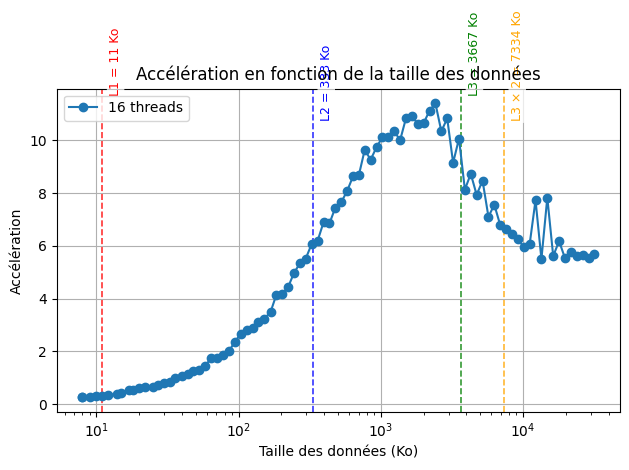

In [30]:
path="results/resultat_partie_04.txt"
afficher_acceleration_toutes_tailles(path, threads=[e for e in range(2,32,8)]+[16,32], caches=caches_core)

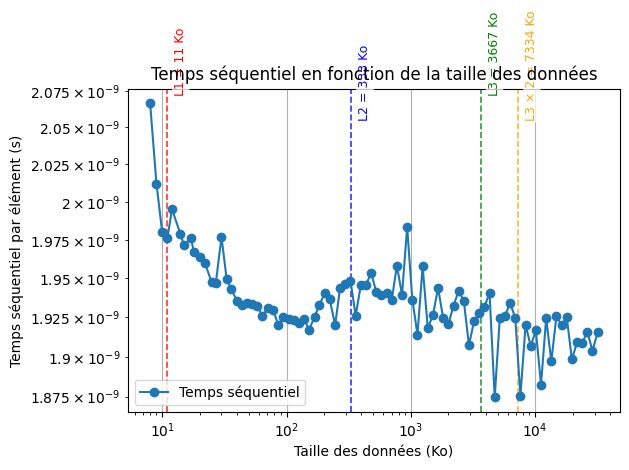

In [31]:
path="results/resultat_partie_04.txt"
afficher_temps_sequentiel_vs_taille(path, caches=caches_core)

> TODO: faire analyse

## Produit scalaire de deux vecteurs avec déséquilibre entre threads

> TODO : je te laisse faire cette question. Il est probable que le static soit peut performat car des threads vont terminer leur processus tandis que d'autre continuerons à travailler donc tu seras bound pas le splus lents. En dynamique tu n'as pas ce problème maiis tu as probablement un cout de syncro peut avantageux avnat une certaines tailles.

## Parallélisation d’un tri bubble-sort

L'algorithme proposé sépare les éléments en deux phases indépendantes (pair et impaire) pour permettre de paralléliser le tri via des opérations indépendantes.

```
(0,1) (2,3) (4,5) (6,7) ... if (step%2)==0
(1,2) (3,4) (5,6) (7,8) ... if (step%2)==1
```

Les boucles for de niveaux deux sont parallélisables. En revanche les phases successives ne sont pas indépendantes car le résultat produit par l'étape $n$ est l'état initial de l'état $n+1$.

```c++
#pragma omp parallel
for (unsigned long int step = N; step > 0; step--) {
    if (step % 2 == 0) {
        #pragma omp for
        for (unsigned long int i = 0; i < N-1; i += 2) {
            if (Tab[i] > Tab[i + 1]) {
                auto buffer = Tab[i];
                Tab[i] = Tab[i + 1];
                Tab[i + 1] = buffer;
    }}} else {
        #pragma omp for
        for (unsigned long int i = 1; i < N-1; i += 2) {
            if (Tab[i] > Tab[i + 1]) {
                auto buffer = Tab[i];
                Tab[i] = Tab[i + 1];
                Tab[i + 1] = buffer;
}}}}
```

Cette première implémentation mutualise l'équipe de threads. Dans la seconde `#pragma omp parallel` est placé à l'intérieur de la boucle principale.

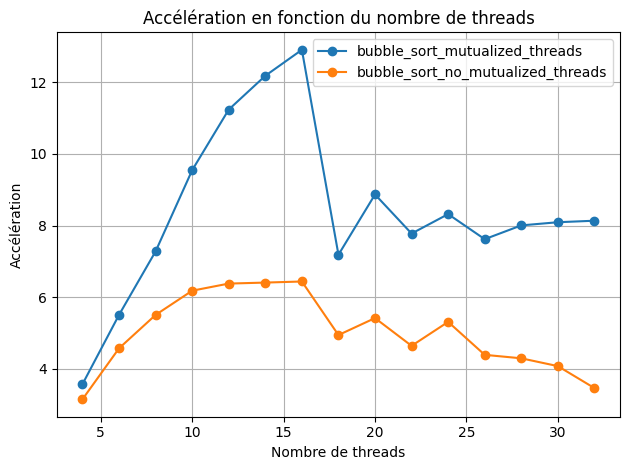

In [13]:
path=["results/bubble_sort_mutualized_threads.txt","results/bubble_sort_no_mutualized_threads.txt"]
afficher_acceleration_vs_coeurs(path)

La première implémentaiton a une région parallèle unique (équipe de threads mutualisée).
La région `#pragma omp parallel` englobe la boucle sur les étapes. L'équipe de threads est créée une seule fois, puis réutilisée à chaque étape de la boucle séquentielle externe. Seule la barrière implicite de fin de `#pragma omp for` subsiste à chaque étape, ce qui est nécessaire à la correction du tri odd-even (chaque phase dépend de la précédente).

L'accélération croît quasi linéairement avec le nombre de threads jusqu'à 16 threads. Ce point correspond au nombre de cœurs physiques de la machine. Au-delà, l'accélération chute brutalement puis se stabilise de 18 à 32 threads. Cette dégradation s'explique par le recours à l'hyper-threading. Deux threads logiques se partagent les unités d'exécution et les caches d'un même cœur. L'algorithme est limité par la bande passante mémoire et la latence des accès en tire peu de bénéfice. S'ajoutent le coût croissant des barrières de synchronisation (en $O(log p)$ ou $O(p)$ selon l'implémentation du runtime) et le déséquilibre possible du nombre d'itérations par thread.

Dans la deuxième implémentation la région parallèle recréée à chaque étape.
`#pragma omp parallel` est placé à l'intérieur de la boucle de niveau 1. La région parallèle est donc ouverte et fermée $N$ fois. Le surcoût provient plutôt de l'entrée et de la sortie de la région : réveil des threads, distribution du travail, barrière de fin de région. Ce coût est proportionnel au nombre de threads et se paie $N$ fois, soit $N \times p$ « activations » pour $N$ étapes et $p$ threads.

L'accélération progresse entre 4 et 10 threads, plafonne entre 10 et 16 threads, puis se dégrade. Au-delà du plafond, le surcoût de gestion de la région parallèle (qui croît avec $p$) l'emporte sur le gain de parallélisation, le travail par étape étant faible (environ $N/2$ comparaisons réparties sur $p$ threads).